In [42]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [43]:
# frame_dir = "/Volumes/PortableSSD/tutrtletest/turtle_test_2_short/frames"
frame_dir = "/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_112336/frames"
frame_dir = "/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037"


num_frames = 11000
background_sample_count = 1000
frames_to_plot = 6

In [44]:
frame_fns = os.listdir(frame_dir)
frame_fns = [fn for fn in frame_fns if fn.endswith(".jpg") or fn.endswith(".png")]
frame_fns.sort()

print(len(frame_fns))
print(frame_fns)

frame_fns = frame_fns[:num_frames]

if not frame_fns:
    raise ValueError("No frames found to process")

background_sample_size = min(background_sample_count, len(frame_fns))
background_sample_indices = np.linspace(
    0, len(frame_fns) - 1, background_sample_size, dtype=int
)
background_frame_fns = [frame_fns[i] for i in background_sample_indices]
print(f"Using {len(background_frame_fns)} evenly spaced frames for background")

9013
['frame_002927_raw_rotated.png', 'frame_002929_raw_rotated.png', 'frame_002930_raw_rotated.png', 'frame_002931_raw_rotated.png', 'frame_002932_raw_rotated.png', 'frame_002933_raw_rotated.png', 'frame_002934_raw_rotated.png', 'frame_002935_raw_rotated.png', 'frame_002936_raw_rotated.png', 'frame_002937_raw_rotated.png', 'frame_002938_raw_rotated.png', 'frame_002939_raw_rotated.png', 'frame_002940_raw_rotated.png', 'frame_002941_raw_rotated.png', 'frame_002942_raw_rotated.png', 'frame_002943_raw_rotated.png', 'frame_002944_raw_rotated.png', 'frame_002945_raw_rotated.png', 'frame_002946_raw_rotated.png', 'frame_002947_raw_rotated.png', 'frame_002948_raw_rotated.png', 'frame_002949_raw_rotated.png', 'frame_002950_raw_rotated.png', 'frame_002951_raw_rotated.png', 'frame_002952_raw_rotated.png', 'frame_002954_raw_rotated.png', 'frame_002955_raw_rotated.png', 'frame_002956_raw_rotated.png', 'frame_002957_raw_rotated.png', 'frame_002958_raw_rotated.png', 'frame_002959_raw_rotated.png', 'f

In [45]:
def load_frame_channel(frame_path, channel=0):
    frame = cv2.imread(frame_path)
    if frame is None:
        raise FileNotFoundError(f"Could not read frame: {frame_path}")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame[:, :, channel]


frame_sum = None
preview_frames = []

for i, frame_fn in enumerate(background_frame_fns):
    frame_path = os.path.join(frame_dir, frame_fn)
    print(frame_path)
    frame = load_frame_channel(frame_path)

    if frame_sum is None:
        frame_shape = frame.shape
        frame_sum = np.zeros(frame_shape, dtype=np.float64)
    elif frame.shape != frame_shape:
        raise ValueError(
            f"Frame shape changed at {frame_path}: {frame.shape} != {frame_shape}"
        )
    
    frame = np.array([cv2.GaussianBlur(f, (15, 15), 0) for f in frame])[:,:,0]
    print(f"Frame {i+1}/{len(background_frame_fns)}: {frame_fn}, shape: {frame.shape}")
    frame_sum += frame
    if i < frames_to_plot:
        preview_frames.append(frame.copy())

if frame_sum is None:
    raise ValueError("No frames found to process")


/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002927_raw_rotated.png
Frame 1/1000: frame_002927_raw_rotated.png, shape: (512, 511)
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002937_raw_rotated.png
Frame 2/1000: frame_002937_raw_rotated.png, shape: (512, 511)
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002946_raw_rotated.png
Frame 3/1000: frame_002946_raw_rotated.png, shape: (512, 511)
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002956_raw_rotated.png
Frame 4/1000: frame_002956_raw_rotated.png, shape: (512, 511)
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002965_raw_rotated.png
Frame 5/1000: frame_002965_raw_rotated.png, shape: (512, 511)
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002974_raw_rotated.png
Frame 6/1000: frame_002974_raw_rotated.png, shape: (512, 511)
/Volumes/PortableSSD/tutrtletest/turtlepond_2026-06-29_111037/frame_002983_raw_rot

9013 1000 (512, 511)
<class 'numpy.ndarray'> (512, 511) -84.153 87.221
<class 'numpy.ndarray'> (512, 511) -85.95 76.099
<class 'numpy.ndarray'> (512, 511) -81.72099 74.341
<class 'numpy.ndarray'> (512, 511) -79.834 83.03
<class 'numpy.ndarray'> (512, 511) -86.804 82.56
<class 'numpy.ndarray'> (512, 511) -85.296 82.57


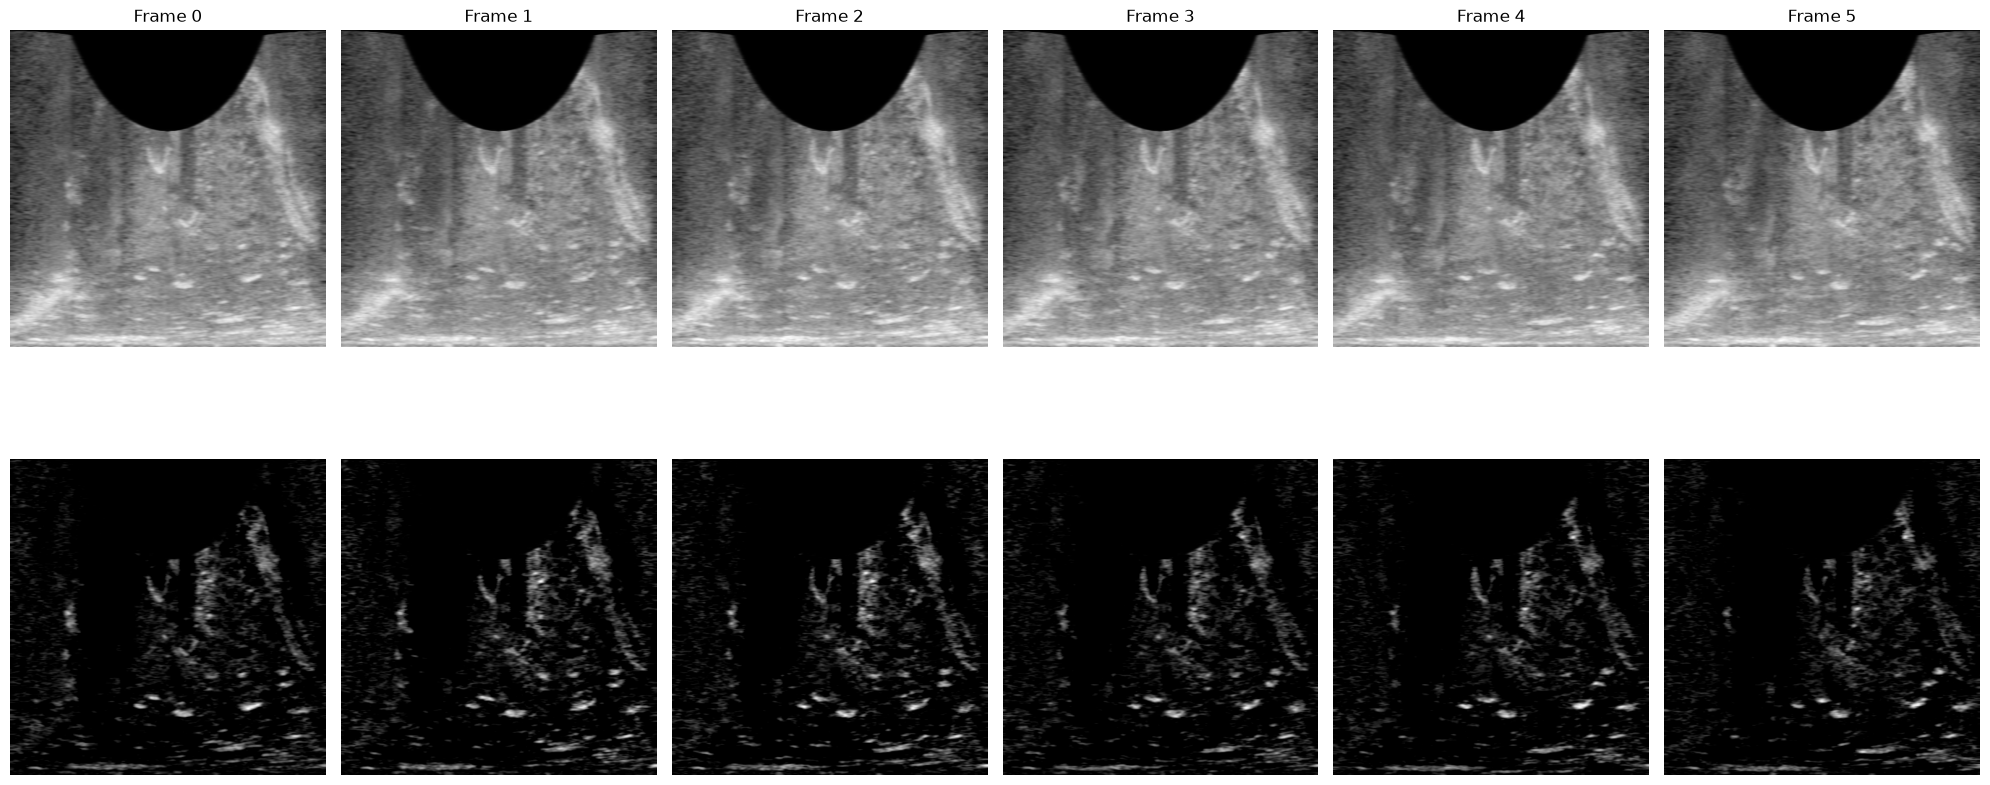

In [46]:
print(len(frame_fns), len(background_frame_fns), frame_shape)

frames_averaged = (frame_sum / len(background_frame_fns)).astype(np.float32)
del frame_sum
# A percentile background still requires retaining many frames in memory.
# frames_averaged = np.percentile(frames, 25, axis=0)

display_count = min(frames_to_plot, len(preview_frames))
fig, ax = plt.subplots(2, display_count, figsize=(20, 10))
if display_count == 1:
    ax = np.array(ax).reshape(2, 1)

for i, frame in enumerate(preview_frames[:display_count]):
    ax[0, i].imshow(frame, cmap="gray")
    ax[0, i].set_title(f"Frame {i}")
    ax[0, i].axis("off")

    frame_bgs = frame.astype(np.float32) - frames_averaged
    print(type(frame_bgs), frame_bgs.shape, np.min(frame_bgs), np.max(frame_bgs))
    frame_bgs = np.clip(frame_bgs, 0, 255)
    ax[1, i].imshow(frame_bgs, cmap="gray")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()


In [47]:
# Keep only small preview arrays in memory. The full background-subtracted
# sequence is generated one frame at a time in the echogram cell below.
out_dir = "gifs"
os.makedirs(out_dir, exist_ok=True)

orig_frames = np.array(preview_frames[:frames_to_plot], dtype=np.uint8)


Generating echogram: 100%|██████████| 9013/9013 [00:44<00:00, 200.51it/s]


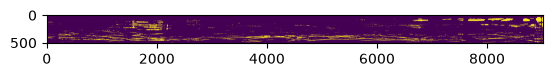

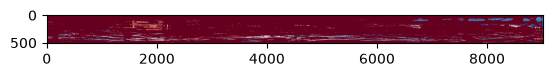

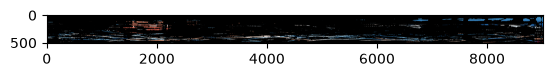

In [48]:
echogram = np.zeros((frame_shape[0], len(frame_fns), 2), dtype=np.uint8)

for i, frame_fn in enumerate(tqdm(frame_fns, desc="Generating echogram")):
    frame_path = os.path.join(frame_dir, frame_fn)
    frame = load_frame_channel(frame_path).astype(np.float32)
    frame = cv2.GaussianBlur(frame, (15, 15), 0)

    bgs_frame = frame - frames_averaged
    bgs_frame = np.clip(bgs_frame, 0, 255) / 255

    bgs_tol = 0.2

    bgs_frame[bgs_frame < bgs_tol] = 0
    bgs_frame[bgs_frame > 0 ] = 1

    # plt.imshow(bgs_frame)
    # plt.show()
    # break


    echogram_brightness = np.max(bgs_frame, axis=1)
    echogram_angle = np.argmax(bgs_frame, axis=1) / bgs_frame.shape[1]

    echogram[:, i, 0] = echogram_brightness * 255
    echogram[:, i, 1] = echogram_angle * 255
    del frame, bgs_frame

plt.imshow(echogram[:, :, 0])
plt.show()
plt.imshow(echogram[:, :, 1], cmap="RdBu")
plt.show()


angle_colour = echogram[:, :, 1]/255
# print("A", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

# angle_colour = (2 * (angle_colour-0.5))
# print("B", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

# angle_colour= (angle_colour) ** 0.5
# print("C", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

# angle_colour = (angle_colour+1)/2
# print("D", angle_colour.shape, np.min(angle_colour), np.max(angle_colour))

angle_colour = plt.get_cmap("RdBu")(angle_colour)[:, :, :3]
brightness = (echogram[:, :, 0, None] / 255)

brightness /= np.max(brightness)
brightness = brightness ** 1.5
angle_colour = angle_colour * brightness
plt.imshow(angle_colour)
plt.show()


In [49]:

# save echogram as a PNG
echogram_out_path = os.path.join(out_dir, "echogram_tol.png")
plt.imsave(echogram_out_path, angle_colour)
